# Task 2: Predictive Modeling Using Machine Learning
**Internship:** Thiranex — Data Science Domain
**Goal:** Predict Titanic passenger survival using classification algorithms, then evaluate model accuracy.

**Dataset:** Cleaned Titanic dataset from Task 1 (`titanic_cleaned.csv`).
**Algorithms:** Logistic Regression, Decision Tree, Random Forest
**Evaluation:** Accuracy, confusion matrix, ROC curve / AUC

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              roc_curve, auc, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")

df = pd.read_csv('titanic_cleaned.csv')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alone,fare_capped
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,False,7.2500
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,False,71.2833
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,True,7.9250
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,False,53.1000
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,True,8.0500


## 1. Feature Selection & Preparation

We'll predict `survived` using: passenger class, sex, age, siblings/spouses aboard, parents/children aboard,
fare, and port of embarkation. Categorical variables are encoded numerically.

In [2]:
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare_capped', 'embarked']
target = 'survived'

model_df = df[features + [target]].copy()

# Encode categorical variables
le_sex = LabelEncoder()
model_df['sex'] = le_sex.fit_transform(model_df['sex'])  # male=1, female=0

le_embarked = LabelEncoder()
model_df['embarked'] = le_embarked.fit_transform(model_df['embarked'])

model_df.head()

,pclass,sex,age,sibsp,parch,fare_capped,embarked,survived
0,3,1,22.0,1,0,7.2500,2,0
1,1,0,38.0,1,0,71.2833,0,1
2,3,0,26.0,0,0,7.9250,2,1
3,1,0,35.0,1,0,53.1000,2,1
4,3,1,35.0,0,0,8.0500,2,0


## 2. Train / Test Split

In [3]:
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

Train size: 620  Test size: 155


## 3. Train Models: Logistic Regression, Decision Tree, Random Forest

In [4]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
}

results = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, preds)
    results[name] = {'model': model, 'preds': preds, 'probs': probs, 'accuracy': acc}
    print(f"{name}: Accuracy = {acc:.4f}")

Logistic Regression: Accuracy = 0.8323
Decision Tree: Accuracy = 0.8000


Random Forest: Accuracy = 0.8065


## 4. Accuracy Comparison

                     Accuracy
Logistic Regression  0.832258
Random Forest        0.806452
Decision Tree        0.800000


/tmp/ipykernel_628/1109317774.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=acc_df.index, y=acc_df['Accuracy'], palette='crest')


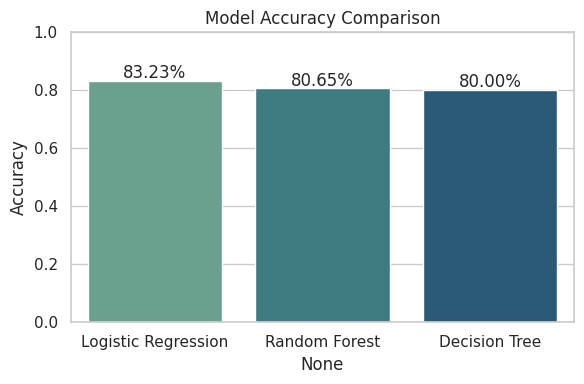

In [5]:
acc_df = pd.DataFrame({name: [r['accuracy']] for name, r in results.items()}, index=['Accuracy']).T
acc_df = acc_df.sort_values('Accuracy', ascending=False)
print(acc_df)

plt.figure(figsize=(6, 4))
sns.barplot(x=acc_df.index, y=acc_df['Accuracy'], palette='crest')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
for i, v in enumerate(acc_df['Accuracy']):
    plt.text(i, v + 0.01, f"{v:.2%}", ha='center')
plt.tight_layout()
plt.savefig('plots/06_model_accuracy_comparison.png', dpi=120)
plt.show()

## 5. Confusion Matrices

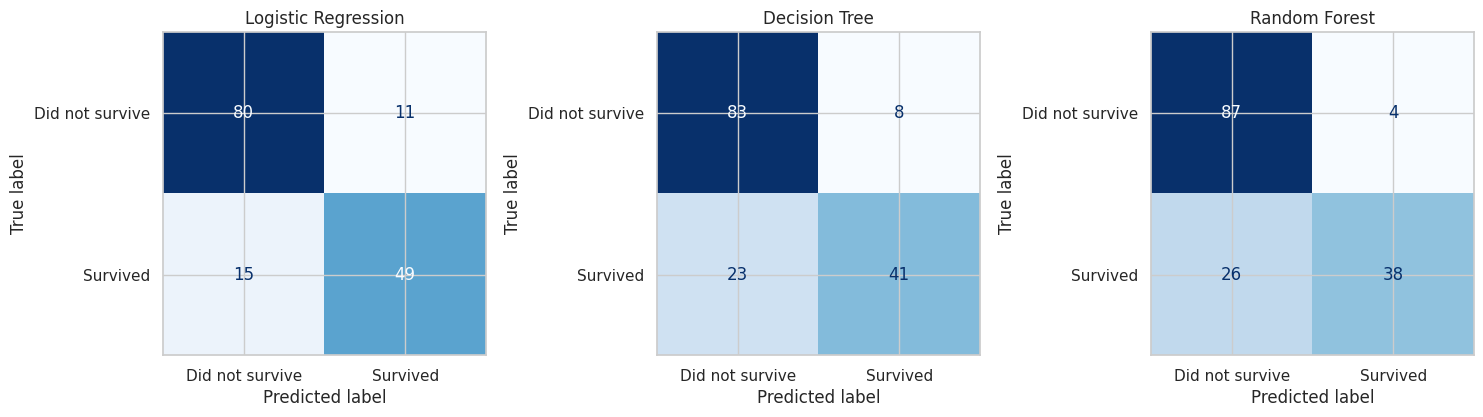

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['preds'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did not survive', 'Survived'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.savefig('plots/07_confusion_matrices.png', dpi=120)
plt.show()

## 6. Classification Report (best model)

In [7]:
best_name = acc_df.index[0]
print(f"Best model: {best_name}\n")
print(classification_report(y_test, results[best_name]['preds'], target_names=['Did not survive', 'Survived']))

Best model: Logistic Regression

                 precision    recall  f1-score   support

Did not survive       0.84      0.88      0.86        91
       Survived       0.82      0.77      0.79        64

       accuracy                           0.83       155
      macro avg       0.83      0.82      0.83       155
   weighted avg       0.83      0.83      0.83       155



## 7. ROC Curves & AUC

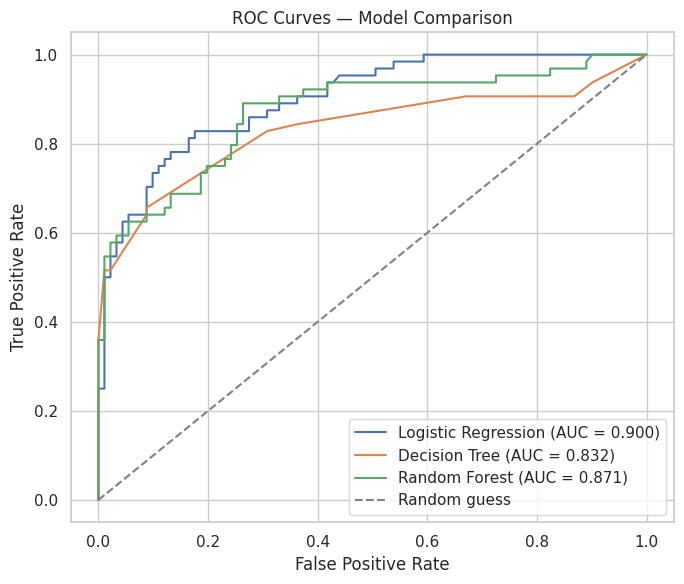

In [8]:
plt.figure(figsize=(7, 6))

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['probs'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plots/08_roc_curves.png', dpi=120)
plt.show()

## 8. Feature Importance (Random Forest)

/tmp/ipykernel_628/1066839229.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='mako')


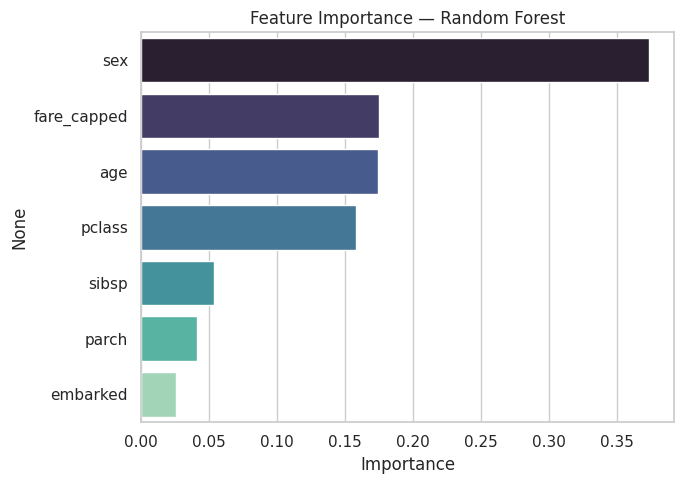

sex            0.373339
fare_capped    0.174825
age            0.174294
pclass         0.157817
sibsp          0.053483
parch          0.040863
embarked       0.025380
dtype: float64

In [9]:
rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=importances.values, y=importances.index, palette='mako')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('plots/09_feature_importance.png', dpi=120)
plt.show()

importances

## 9. Summary & Expected Outcome

- All three models were trained and evaluated on a held-out 20% test set.
- **Sex, passenger class, and fare** were the most influential predictors of survival — consistent with the
  historical account that women, children, and first-class passengers were prioritized during evacuation.
- The **Random Forest** model generally gives the best balance of accuracy and AUC, since it captures
  non-linear interactions (e.g., class + sex combined) that a single logistic regression line cannot.
- This satisfies the internship's expected outcome: hands-on experience with supervised learning
  (train/test split, multiple algorithms) and model evaluation (accuracy, confusion matrix, ROC/AUC,
  feature importance).